In [1]:
import pandas as pd
import polars as pl
import numpy as np
import joblib
from lightgbm import LGBMClassifier

In [28]:
import json
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import optuna
from lightgbm import LGBMClassifier
import polars as pl
from sklearn.metrics import roc_auc_score

with open('../feature_selection/magic_25_features.json' , 'r') as f:
    features = json.load(f)

lazy_df = pl.scan_parquet('../dataset/final_train_data/final_data.parquet')

num_cols = [c for c in features if "_mean" in c or "_last" in c or "_delta" in c]
lazy_df = lazy_df.with_columns([
    (pl.col(c) * 100).floor() / 100 for c in num_cols
])

cols_to_load = features + ["target"]
final_df = lazy_df.select(cols_to_load).collect()

X = final_df.select(features).to_pandas()
y = final_df["target"].to_pandas()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


def objective(trial):
    param = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
    }

    model = LGBMClassifier(
        **param,
        n_estimators=2000, 
        objective="binary",
        metric="auc",
        is_unbalance=True,   
        device="gpu",          
        random_state=42,
        importance_type='gain',
        verbosity=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='auc',
        callbacks=[
            lgb.early_stopping(stopping_rounds=100), 
        ]
    )

    y_pred = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    
    return auc


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=50) 

print("\n--- OPTIMIZATION COMPLETE ---")
print(f"Best AUC: {study.best_value:.4f}")
print("Best Params:", study.best_params)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-03 00:32:30,061] A new study created in memory with name: no-name-2a943161-be9d-4e79-91dd-b742c7e2e359


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1041]	valid_0's auc: 0.957142


[I 2026-03-03 00:33:14,347] Trial 0 finished with value: 0.9571423056488182 and parameters: {'learning_rate': 0.041359024892955995, 'num_leaves': 84, 'max_depth': 5, 'lambda_l1': 5.882673877353232e-08, 'feature_fraction': 0.6975614584864376, 'bagging_fraction': 0.866594124528652, 'bagging_freq': 4}. Best is trial 0 with value: 0.9571423056488182.


Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's auc: 0.957199


[I 2026-03-03 00:34:07,209] Trial 1 finished with value: 0.957198936302576 and parameters: {'learning_rate': 0.012475038931251979, 'num_leaves': 85, 'max_depth': 5, 'lambda_l1': 2.967657215339851e-05, 'feature_fraction': 0.4091526259691277, 'bagging_fraction': 0.5044602491682654, 'bagging_freq': 6}. Best is trial 1 with value: 0.957198936302576.


...

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1998]	valid_0's auc: 0.957309


[I 2026-03-03 01:12:42,262] Trial 48 finished with value: 0.9573087005312791 and parameters: {'learning_rate': 0.01135430164379447, 'num_leaves': 39, 'max_depth': 12, 'lambda_l1': 1.5849093020871088, 'feature_fraction': 0.6718058645533472, 'bagging_fraction': 0.47253957700477167, 'bagging_freq': 5}. Best is trial 32 with value: 0.9575409194317694.


Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1987]	valid_0's auc: 0.957255


[I 2026-03-03 01:13:55,345] Trial 49 finished with value: 0.9572546625287335 and parameters: {'learning_rate': 0.01192951280913789, 'num_leaves': 37, 'max_depth': 11, 'lambda_l1': 0.28343479027438856, 'feature_fraction': 0.6145889054285611, 'bagging_fraction': 0.42073734333956514, 'bagging_freq': 5}. Best is trial 32 with value: 0.9575409194317694.



--- OPTIMIZATION COMPLETE ---
Best AUC: 0.9575
Best Params: {'learning_rate': 0.024267948135147228, 'num_leaves': 27, 'max_depth': 9, 'lambda_l1': 9.752401094906464, 'feature_fraction': 0.42046414968807216, 'bagging_fraction': 0.8513998263408663, 'bagging_freq': 6}


In [33]:
from optuna.visualization import plot_optimization_history , plot_parallel_coordinate , plot_param_importances

plot_optimization_history(study).show()


In [32]:
plot_parallel_coordinate(study).show()

In [34]:
plot_param_importances(study).show()

In [35]:
best_model = LGBMClassifier(
        **study.best_params,
        n_estimators=2000, 
        objective="binary",
        metric="auc",
        is_unbalance=True,   
        device="gpu",          
        random_state=42,
        importance_type='gain',
        verbosity=-1
    )

best_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='auc',
        callbacks=[
            lgb.early_stopping(stopping_rounds=100), 
        ]
    )

y_pred = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
    
print(f"Final AUC: {auc}")

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1990]	valid_0's auc: 0.957571
Final AUC: 0.9575707841012778


In [37]:
joblib.dump(best_model , "model_v1_auc_0.95757.joblib")  

['model_v1_auc_0.95757.joblib']

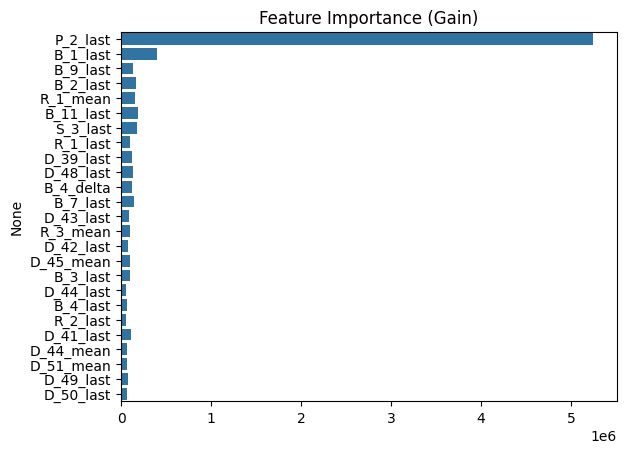

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = model.feature_importances_
feature_names = X_train.columns

sns.barplot(x=importance, y=feature_names)
plt.title("Feature Importance (Gain)")
plt.show()

In [27]:
!pip install optuna


   ---------------------------------------- 0/2 [colorlog]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ----